
Datasets Loaded Successfully

Training Logistic Regression...
Training KNN...
Training SVM...

All Models Trained Successfully

Logistic Regression Evaluation

Accuracy : 0.9692
Precision: 0.2500
Recall   : 1.0000
F1-Score : 0.4000
AUC Score: 1.0000

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.97      0.98       193
           1       0.25      1.00      0.40         2

    accuracy                           0.97       195
   macro avg       0.62      0.98      0.69       195
weighted avg       0.99      0.97      0.98       195



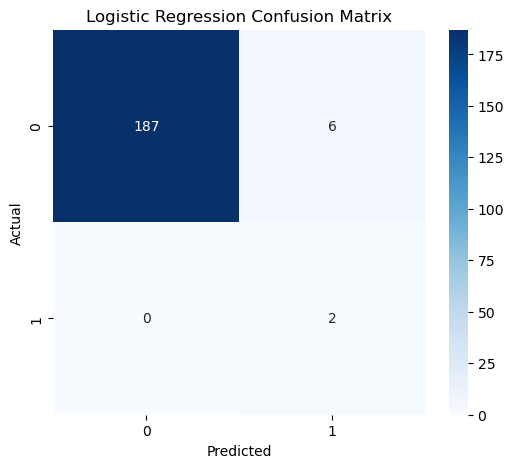

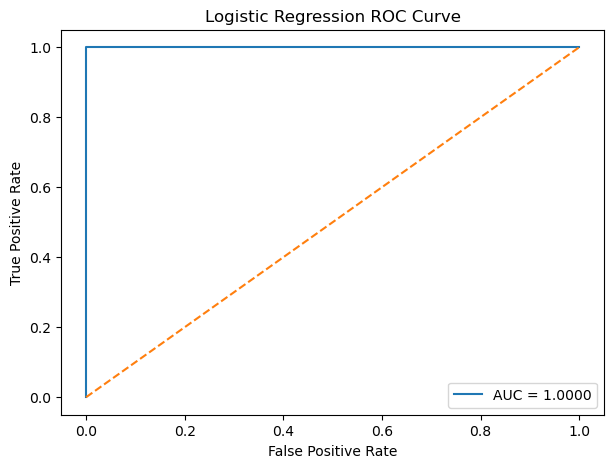


KNN Evaluation

Accuracy : 0.9897
Precision: 0.0000
Recall   : 0.0000
F1-Score : 0.0000
AUC Score: 0.7448

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       193
           1       0.00      0.00      0.00         2

    accuracy                           0.99       195
   macro avg       0.49      0.50      0.50       195
weighted avg       0.98      0.99      0.98       195



D:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: Unde

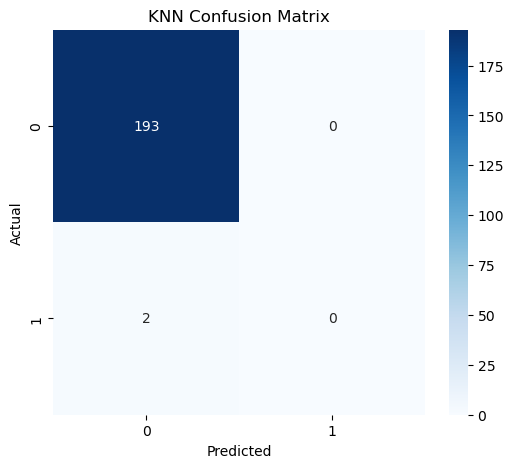

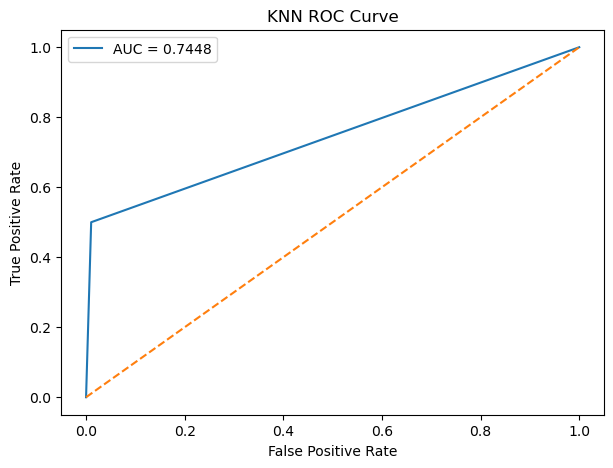


SVM Evaluation

Accuracy : 0.9897
Precision: 0.0000
Recall   : 0.0000
F1-Score : 0.0000
AUC Score: 1.0000

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       193
           1       0.00      0.00      0.00         2

    accuracy                           0.99       195
   macro avg       0.49      0.50      0.50       195
weighted avg       0.98      0.99      0.98       195



D:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: Unde

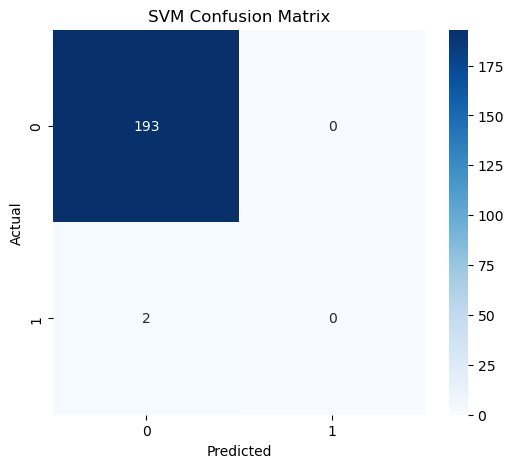

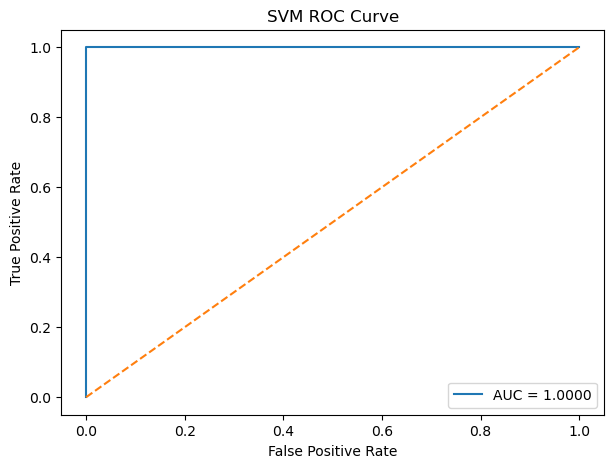


MODEL COMPARISON
                 Model  Accuracy  Precision  Recall  F1-Score  AUC Score
0  Logistic Regression  0.969231       0.25     1.0       0.4   1.000000
1                  KNN  0.989744       0.00     0.0       0.0   0.744819
2                  SVM  0.989744       0.00     0.0       0.0   1.000000


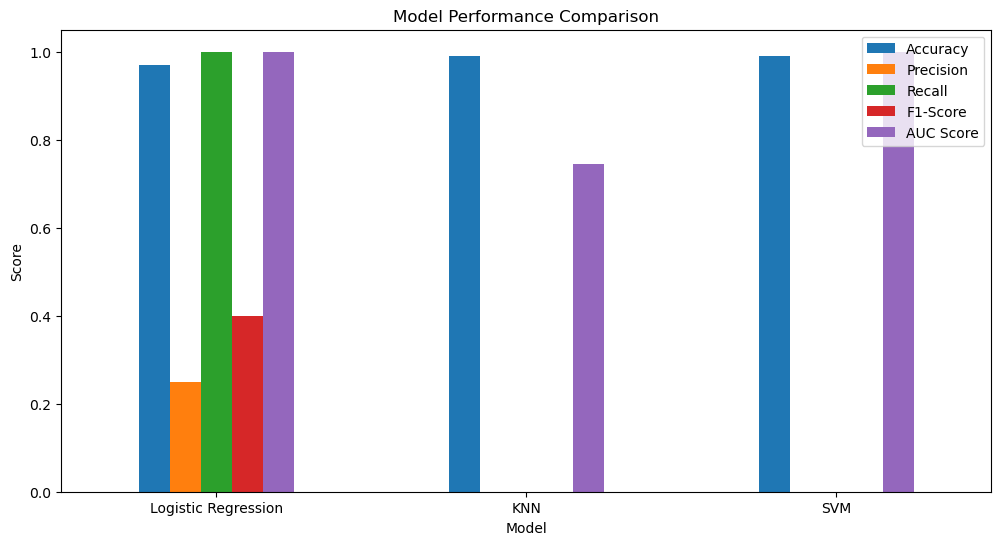


MODEL TRAINING COMPLETED

Generated File:
1. Model_Comparison_Results.csv

BEST MODEL FOR FRAUD DETECTION
Model        Logistic Regression
Accuracy                0.969231
Precision                   0.25
Recall                       1.0
F1-Score                     0.4
AUC Score                    1.0
Name: 0, dtype: object


In [1]:
# ============================================================
# CREDIT CARD FRAUD DETECTION
# MODEL TRAINING + EVALUATION
# Logistic Regression + KNN + SVM
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)


# ============================================================
# 2. LOAD DATASETS
# ============================================================

# KNN DATASETS (Normalized)

X_train_knn = pd.read_csv(
    "KNN_X_Train_Normalized.csv"
)

X_test_knn = pd.read_csv(
    "KNN_X_Test_Normalized.csv"
)


# LR + SVM DATASETS (Standardized)

X_train_std = pd.read_csv(
    "LR_SVM_X_Train_Standardized.csv"
)

X_test_std = pd.read_csv(
    "LR_SVM_X_Test_Standardized.csv"
)


# TARGET DATASETS

y_train = pd.read_csv(
    "Y_Train.csv"
)

y_test = pd.read_csv(
    "Y_Test.csv"
)


# Convert target into 1D array

y_train = y_train.values.ravel()

y_test = y_test.values.ravel()


print("\nDatasets Loaded Successfully")


# ============================================================
# 3. CREATE MODELS
# ============================================================

# Logistic Regression

lr_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)


# KNN

knn_model = KNeighborsClassifier(
    n_neighbors=5
)


# SVM

svm_model = SVC(
    kernel='rbf',
    probability=True,
    class_weight='balanced',
    random_state=42
)


# ============================================================
# 4. TRAIN MODELS
# ============================================================

print("\nTraining Logistic Regression...")
lr_model.fit(X_train_std, y_train)

print("Training KNN...")
knn_model.fit(X_train_knn, y_train)

print("Training SVM...")
svm_model.fit(X_train_std, y_train)

print("\nAll Models Trained Successfully")


# ============================================================
# 5. MODEL PREDICTIONS
# ============================================================

# Logistic Regression

lr_pred = lr_model.predict(X_test_std)

lr_prob = lr_model.predict_proba(X_test_std)[:,1]


# KNN

knn_pred = knn_model.predict(X_test_knn)

knn_prob = knn_model.predict_proba(X_test_knn)[:,1]


# SVM

svm_pred = svm_model.predict(X_test_std)

svm_prob = svm_model.predict_proba(X_test_std)[:,1]


# ============================================================
# 6. EVALUATION FUNCTION
# ============================================================

def evaluate_model(
    y_true,
    y_pred,
    y_prob,
    model_name
):

    print("\n===================================")
    print(f"{model_name} Evaluation")
    print("===================================")

    # Accuracy
    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    # Precision
    precision = precision_score(
        y_true,
        y_pred
    )

    # Recall
    recall = recall_score(
        y_true,
        y_pred
    )

    # F1 Score
    f1 = f1_score(
        y_true,
        y_pred
    )

    # ROC AUC
    auc = roc_auc_score(
        y_true,
        y_prob
    )

    print(f"\nAccuracy : {accuracy:.4f}")

    print(f"Precision: {precision:.4f}")

    print(f"Recall   : {recall:.4f}")

    print(f"F1-Score : {f1:.4f}")

    print(f"AUC Score: {auc:.4f}")


    # ========================================================
    # CLASSIFICATION REPORT
    # ========================================================
    print("\nClassification Report:\n")

    print(
        classification_report(
            y_true,
            y_pred
        )
    )


    # ========================================================
    # CONFUSION MATRIX
    # ========================================================
    cm = confusion_matrix(
        y_true,
        y_pred
    )

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(
        f"{model_name} Confusion Matrix"
    )

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()


    # ========================================================
    # ROC CURVE
    # ========================================================
    fpr, tpr, thresholds = roc_curve(
        y_true,
        y_prob
    )

    plt.figure(figsize=(7,5))

    plt.plot(
        fpr,
        tpr,
        label=f"AUC = {auc:.4f}"
    )

    plt.plot(
        [0,1],
        [0,1],
        linestyle='--'
    )

    plt.title(
        f"{model_name} ROC Curve"
    )

    plt.xlabel("False Positive Rate")

    plt.ylabel("True Positive Rate")

    plt.legend()

    plt.show()

    return accuracy, precision, recall, f1, auc


# ============================================================
# 7. EVALUATE LOGISTIC REGRESSION
# ============================================================

lr_results = evaluate_model(

    y_test,
    lr_pred,
    lr_prob,
    "Logistic Regression"
)


# ============================================================
# 8. EVALUATE KNN
# ============================================================

knn_results = evaluate_model(

    y_test,
    knn_pred,
    knn_prob,
    "KNN"
)


# ============================================================
# 9. EVALUATE SVM
# ============================================================

svm_results = evaluate_model(

    y_test,
    svm_pred,
    svm_prob,
    "SVM"
)


# ============================================================
# 10. MODEL COMPARISON TABLE
# ============================================================

results_df = pd.DataFrame({

    'Model': [

        'Logistic Regression',

        'KNN',

        'SVM'
    ],

    'Accuracy': [

        lr_results[0],

        knn_results[0],

        svm_results[0]
    ],

    'Precision': [

        lr_results[1],

        knn_results[1],

        svm_results[1]
    ],

    'Recall': [

        lr_results[2],

        knn_results[2],

        svm_results[2]
    ],

    'F1-Score': [

        lr_results[3],

        knn_results[3],

        svm_results[3]
    ],

    'AUC Score': [

        lr_results[4],

        knn_results[4],

        svm_results[4]
    ]
})


print("\n===================================")
print("MODEL COMPARISON")
print("===================================")

print(results_df)


# ============================================================
# 11. BAR GRAPH FOR MODEL COMPARISON
# ============================================================

results_df.set_index('Model').plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Model Performance Comparison")

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.show()


# ============================================================
# 12. SAVE MODEL RESULTS
# ============================================================

results_df.to_csv(
    "Model_Comparison_Results.csv",
    index=False
)

print("\n===================================")

print("MODEL TRAINING COMPLETED")

print("===================================")

print("\nGenerated File:")

print("1. Model_Comparison_Results.csv")


# ============================================================
# 13. BEST MODEL
# ============================================================

best_model = results_df.sort_values(
    by='Recall',
    ascending=False
).iloc[0]

print("\n===================================")

print("BEST MODEL FOR FRAUD DETECTION")

print("===================================")

print(best_model)